In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rockphypy as rp

In [34]:
df = pd.read_csv('../Datasets/DataAVO2.csv')
df.head()

,Index,Brine_Vp,Brine_Vs,Brine_p,Shale_VP,Shale_Vs,Shale_Vs.1,Gas_Vp,Gas_Vs,Gas_p
0,1,3.28,1.68,2.19,3.27,1.65,2.20,3.04,1.74,2.05
1,2,4.06,2.03,2.40,4.69,2.61,2.49,3.70,2.06,2.26
2,3,3.85,2.24,2.24,2.77,1.52,2.29,3.08,2.34,2.14
3,4,4.06,2.34,2.30,4.06,2.18,2.58,3.62,2.58,2.30
4,5,3.21,1.79,2.22,3.05,1.69,2.34,2.91,1.85,2.01


In [30]:
def zoeppritz(vp1, vs1, rho1, vp2, vs2, rho2, theta_deg):
    theta = np.deg2rad(theta_deg)
    p = np.sin(theta) / vp1  # ray parameter

    # Snell's law: transmitted angles
    cos1 = np.cos(theta)
    sin2 = p * vp2
    cos2 = np.sqrt(1 - sin2**2)

    # Zoeppritz matrix entries (Aki & Richards style)
    a = rho2 * (1 - 2 * vs2**2 * p**2)
    b = rho1 * (1 - 2 * vs1**2 * p**2)
    c = rho2 * vs2**2
    d = rho1 * vs1**2

    E = b * cos1 + a * cos2
    F = b * sin2 - a * sin1
    G = c * cos1 + d * cos2
    H = c * sin2 - d * sin1

    # Solve linear system for Rpp, Rps, Tpp, Tps
    M = np.array([
        [E, F, -E, -F],
        [G, H, -G, -H],
        [F, -E, F, -E],
        [H, -G, H, -G],
    ])
    rhs = np.array([b * cos1 - a * cos2,
                    d * sin1 - c * sin2,
                    b * sin1 + a * sin2,
                    d * cos1 + c * cos2])

    Rpp, Rps, Tpp, Tps = np.linalg.solve(M, rhs)
    return Rpp, Rps, Tpp, Tps

/usr/local/python/3.12.1/lib/python3.12/site-packages/rockphypy/AVO.py:186: RuntimeWarning: invalid value encountered in arcsin
  theta2  =np.arcsin(p*vp2)


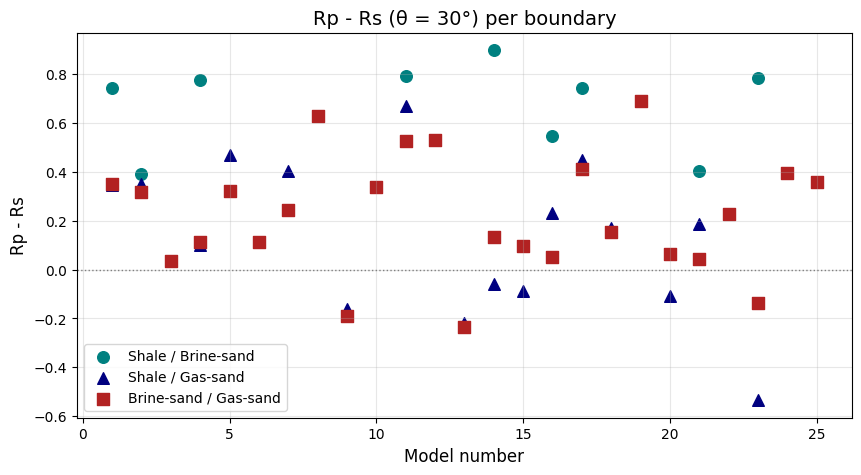

In [ ]:
# Clean column names (strip whitespace/newlines)
df.columns = df.columns.str.strip()

# Convert densities to kg/m3
df['rho_shale'] = df['Shale_Vs.1'] * 1000
df['rho_gas']   = df['Gas_p']      * 1000
df['rho_brine'] = df['Brine_p']    * 1000

theta = 30  # incident angle in degrees

rpp_sg, rps_sg = [], []   # Shale -> Gas-sand
rpp_sb, rps_sb = [], []   # Shale -> Brine-sand
rpp_bg, rps_bg = [], []   # Brine-sand -> Gas-sand

for _, row in df.iterrows():
    # Shale–Gas-sand
    Rpp, Rps = rp.AVO.zoeppritz(
        row['Shale_VP'], row['Shale_Vs'], row['rho_shale'],
        row['Gas_Vp'],   row['Gas_Vs'],   row['rho_gas'],
        theta
    )
    rpp_sg.append(Rpp); rps_sg.append(Rps)

    # Shale–Brine-sand
    Rpp, Rps = rp.AVO.zoeppritz(
        row['Shale_VP'],  row['Shale_Vs'],  row['rho_shale'],
        row['Brine_Vp'],  row['Brine_Vs'],  row['rho_brine'],
        theta
    )
    rpp_sb.append(Rpp); rps_sb.append(Rps)

    # Brine-sand–Gas-sand
    Rpp, Rps = rp.AVO.zoeppritz(
        row['Brine_Vp'], row['Brine_Vs'], row['rho_brine'],
        row['Gas_Vp'],   row['Gas_Vs'],   row['rho_gas'],
        theta
    )
    rpp_bg.append(Rpp); rps_bg.append(Rps)

# Save Rpp/Rps to dataframe (used by fluid factor cell below)
df['Rpp_shale_gas']   = rpp_sg;   df['Rps_shale_gas']   = rps_sg
df['Rpp_shale_brine'] = rpp_sb;   df['Rps_shale_brine'] = rps_sb
df['Rpp_brine_gas']   = rpp_bg;   df['Rps_brine_gas']   = rps_bg

# Compute Rp - Rs for each interface
df['Rp_minus_Rs_shale_gas']   = df['Rpp_shale_gas']   - df['Rps_shale_gas']
df['Rp_minus_Rs_shale_brine'] = df['Rpp_shale_brine'] - df['Rps_shale_brine']
df['Rp_minus_Rs_brine_gas']   = df['Rpp_brine_gas']   - df['Rps_brine_gas']

x = df['Index']

plt.figure(figsize=(10, 5))
plt.scatter(x, df['Rp_minus_Rs_shale_brine'], marker='o', s=70, label='Shale / Brine-sand',    color='teal')
plt.scatter(x, df['Rp_minus_Rs_shale_gas'],   marker='^', s=70, label='Shale / Gas-sand',      color='navy')
plt.scatter(x, df['Rp_minus_Rs_brine_gas'],   marker='s', s=70, label='Brine-sand / Gas-sand', color='firebrick')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Model number', fontsize=12)
plt.ylabel('Rp - Rs', fontsize=12)
plt.title(f'Rp - Rs (θ = {theta}°) per boundary', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Fluid Factor

The **Fluid Factor** $F$ (Smith & Gidlow, 1987) is defined as:

$$F = R_P - 1.16 \frac{V_S}{V_P} R_S$$

Where $V_S/V_P$ is the background ratio for brine-saturated sand (≈ 0.5). A deviation from $F = 0$ indicates a fluid anomaly (gas).


In [ ]:
def fluid_factor(Rp, Rs, Vs, Vp):
    """
    Smith & Gidlow (1987) Fluid Factor:
        F = Rp - 1.16 * (Vs/Vp) * Rs

    F ≈ 0  → brine-sand (on the fluid line)
    F ≠ 0  → gas anomaly (deviation from fluid line)
    """
    return Rp - 1.16 * (Vs / Vp) * Rs


# Use Rpp/Rps already computed and stored in cell above
df['F_shale_gas']   = fluid_factor(
    df['Rpp_shale_gas'],   df['Rps_shale_gas'],
    df['Shale_Vs'], df['Shale_VP']
)
df['F_shale_brine'] = fluid_factor(
    df['Rpp_shale_brine'], df['Rps_shale_brine'],
    df['Shale_Vs'], df['Shale_VP']
)
df['F_brine_gas']   = fluid_factor(
    df['Rpp_shale_gas'],   df['Rps_shale_gas'],
    df['Brine_Vs'], df['Brine_Vp']
)

x = df['Index']

plt.figure(figsize=(10, 5))
plt.scatter(x, df['F_shale_brine'], marker='o', s=70, label='Shale / Brine-sand',    color='teal')
plt.scatter(x, df['F_shale_gas'],   marker='^', s=70, label='Shale / Gas-sand',      color='navy')
plt.scatter(x, df['F_brine_gas'],   marker='s', s=70, label='Brine-sand / Gas-sand', color='firebrick')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Model number', fontsize=12)
plt.ylabel('Fluid Factor  F', fontsize=12)
plt.title(r'Fluid Factor  $F = R_P - 1.16\,\frac{V_S}{V_P}\,R_S$', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

KeyError: 'Rpp_shale_gas'